In [ ]:
#| include: false

# /// script
# requires-python = ">=3.10"
# dependencies = [
#   "matplotlib",
#   "numpy",
#   "pandas",
#   "pymc",
#   "scipy",
#   "seaborn",
# ]
# ///


In [2]:
%matplotlib inline
import numpy as np
import scipy as sp
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import pandas as pd
pd.set_option('display.width', 500)
pd.set_option('display.max_columns', 100)
pd.set_option('display.notebook_repr_html', True)
import seaborn as sns
sns.set_style('whitegrid')
sns.set_context('poster')
import pymc as pm
import pytensor.tensor as pt
import arviz as az

We'll first load the tightly coupled gaussian data from the notebook where we did the non-marginalized sampling.

In [3]:
data=np.loadtxt("data/3gv2.dat")
data.shape

(100,)

### The choice of a prior

The Dirichlet is the multi-dimensional analog of the Beta. Higher values force you to be more central. 

## The log-sum-exp trick and mixtures

From the Stan Manual:

>The log sum of exponentials function is used to define mixtures on the log scale. It is defined for two inputs by

$$log\_sum\_exp(a, b) = log(exp(a) + exp(b)).$$

>If a and b are probabilities on the log scale, then $exp(a) + exp(b)$ is their sum on the linear scale, and the outer log converts the result back to the log scale; to summarize, log_sum_exp does linear addition on the log scale. The reason to use the built-in log_sum_exp function is that it can prevent underflow and overflow in the exponentiation, by calculating the result as

$$log \left( exp(a) + exp(b) \right)  = c + log  exp(a − c) + exp(b − c)  ,$$

>where c = max(a, b). In this evaluation, one of the terms, a − c or b − c, is zero and the other is negative, thus eliminating the possibility of overflow or underflow in the leading term and eking the most arithmetic precision possible out of the operation.

As one can see below, `pymc3` uses the same definition

From https://github.com/pymc-devs/pymc3/blob/master/pymc3/math.py#L27

```python
def logsumexp(x, axis=None):
    # Adapted from https://github.com/Theano/Theano/issues/1563
    x_max = tt.max(x, axis=axis, keepdims=True)
    return tt.log(tt.sum(tt.exp(x - x_max), axis=axis, keepdims=True)) + x_max
```

For example (as taken from the Stan Manual), the mixture of $N(−1, 2)$ and $N(3, 1)$ with mixing proportion $\lambda = (0.3, 0.7)$:

$$logp(y \vert \lambda, \mu, \sigma)$$

$$= log\left(0.3×N(y \vert −1,2) + 0.7×N(y \vert 3,1)\right)$$

$$= log\left(exp(log(0.3 × N(y \vert − 1, 2)))  + exp(log(0.7 × N(y \vert 3, 1))) \right)$$

$$= \mathtt{log\_sum\_exp}\left(log(0.3) + log\,N(y \vert − 1, 2), log(0.7) + log\, N(y \vert 3, 1) \right).$$

where `log_sum_exp` is the function as defined above.

This generalizes to the case of more mixture components.

This is thus a custon distribution `logp` we must define. If we do this, we can go directly from the Dirichlet priors for $p$ and forget the `category` variable

## PyMC implements the log-sum-exp directly

Lets see the source here to see how its done:

https://github.com/pymc-devs/pymc/blob/main/pymc/distributions/mixture.py

There is a marginalized Gaussian Mixture model available, as well as a general mixture. We'll use the `NormalMixture`, to which we must provide mixing weights and components.

In [4]:
with pm.Model() as mof3:
    p = pm.Dirichlet('p', a=np.array([10., 10., 10.]), shape=3)
    means = pm.Normal('means', mu=0, sigma=10, shape=3,
                  transform=pm.distributions.transforms.ordered,
                  initval=np.array([-1, 0, 1]))

    points = pm.NormalMixture('obs', p, mu=means, sigma=1, observed=data)

In [5]:
with mof3:
    trace_mof3 = pm.sample(10000, tune=2000, target_accept=0.95)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [p, means]


/Users/rahul/Library/Caches/uv/archive-v0/WJgPh5nRFVZl0DU9tt8M7/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_000 tune and 10_000 draw iterations (8_000 + 40_000 draws total) took 17 seconds.


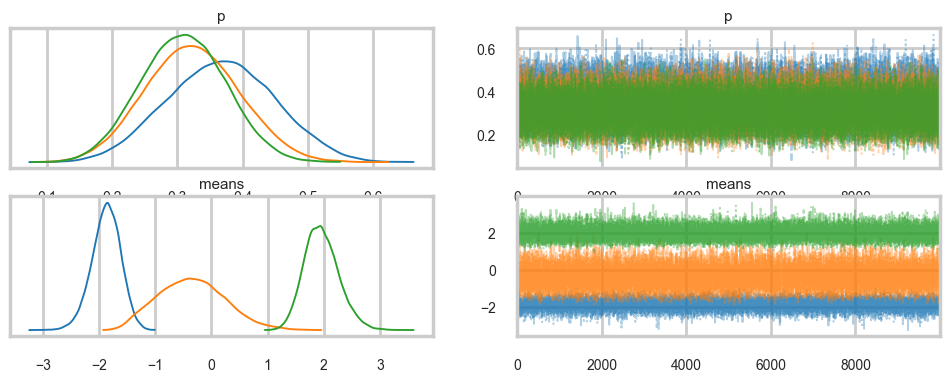

In [6]:
az.plot_trace(trace_mof3, combined=True);

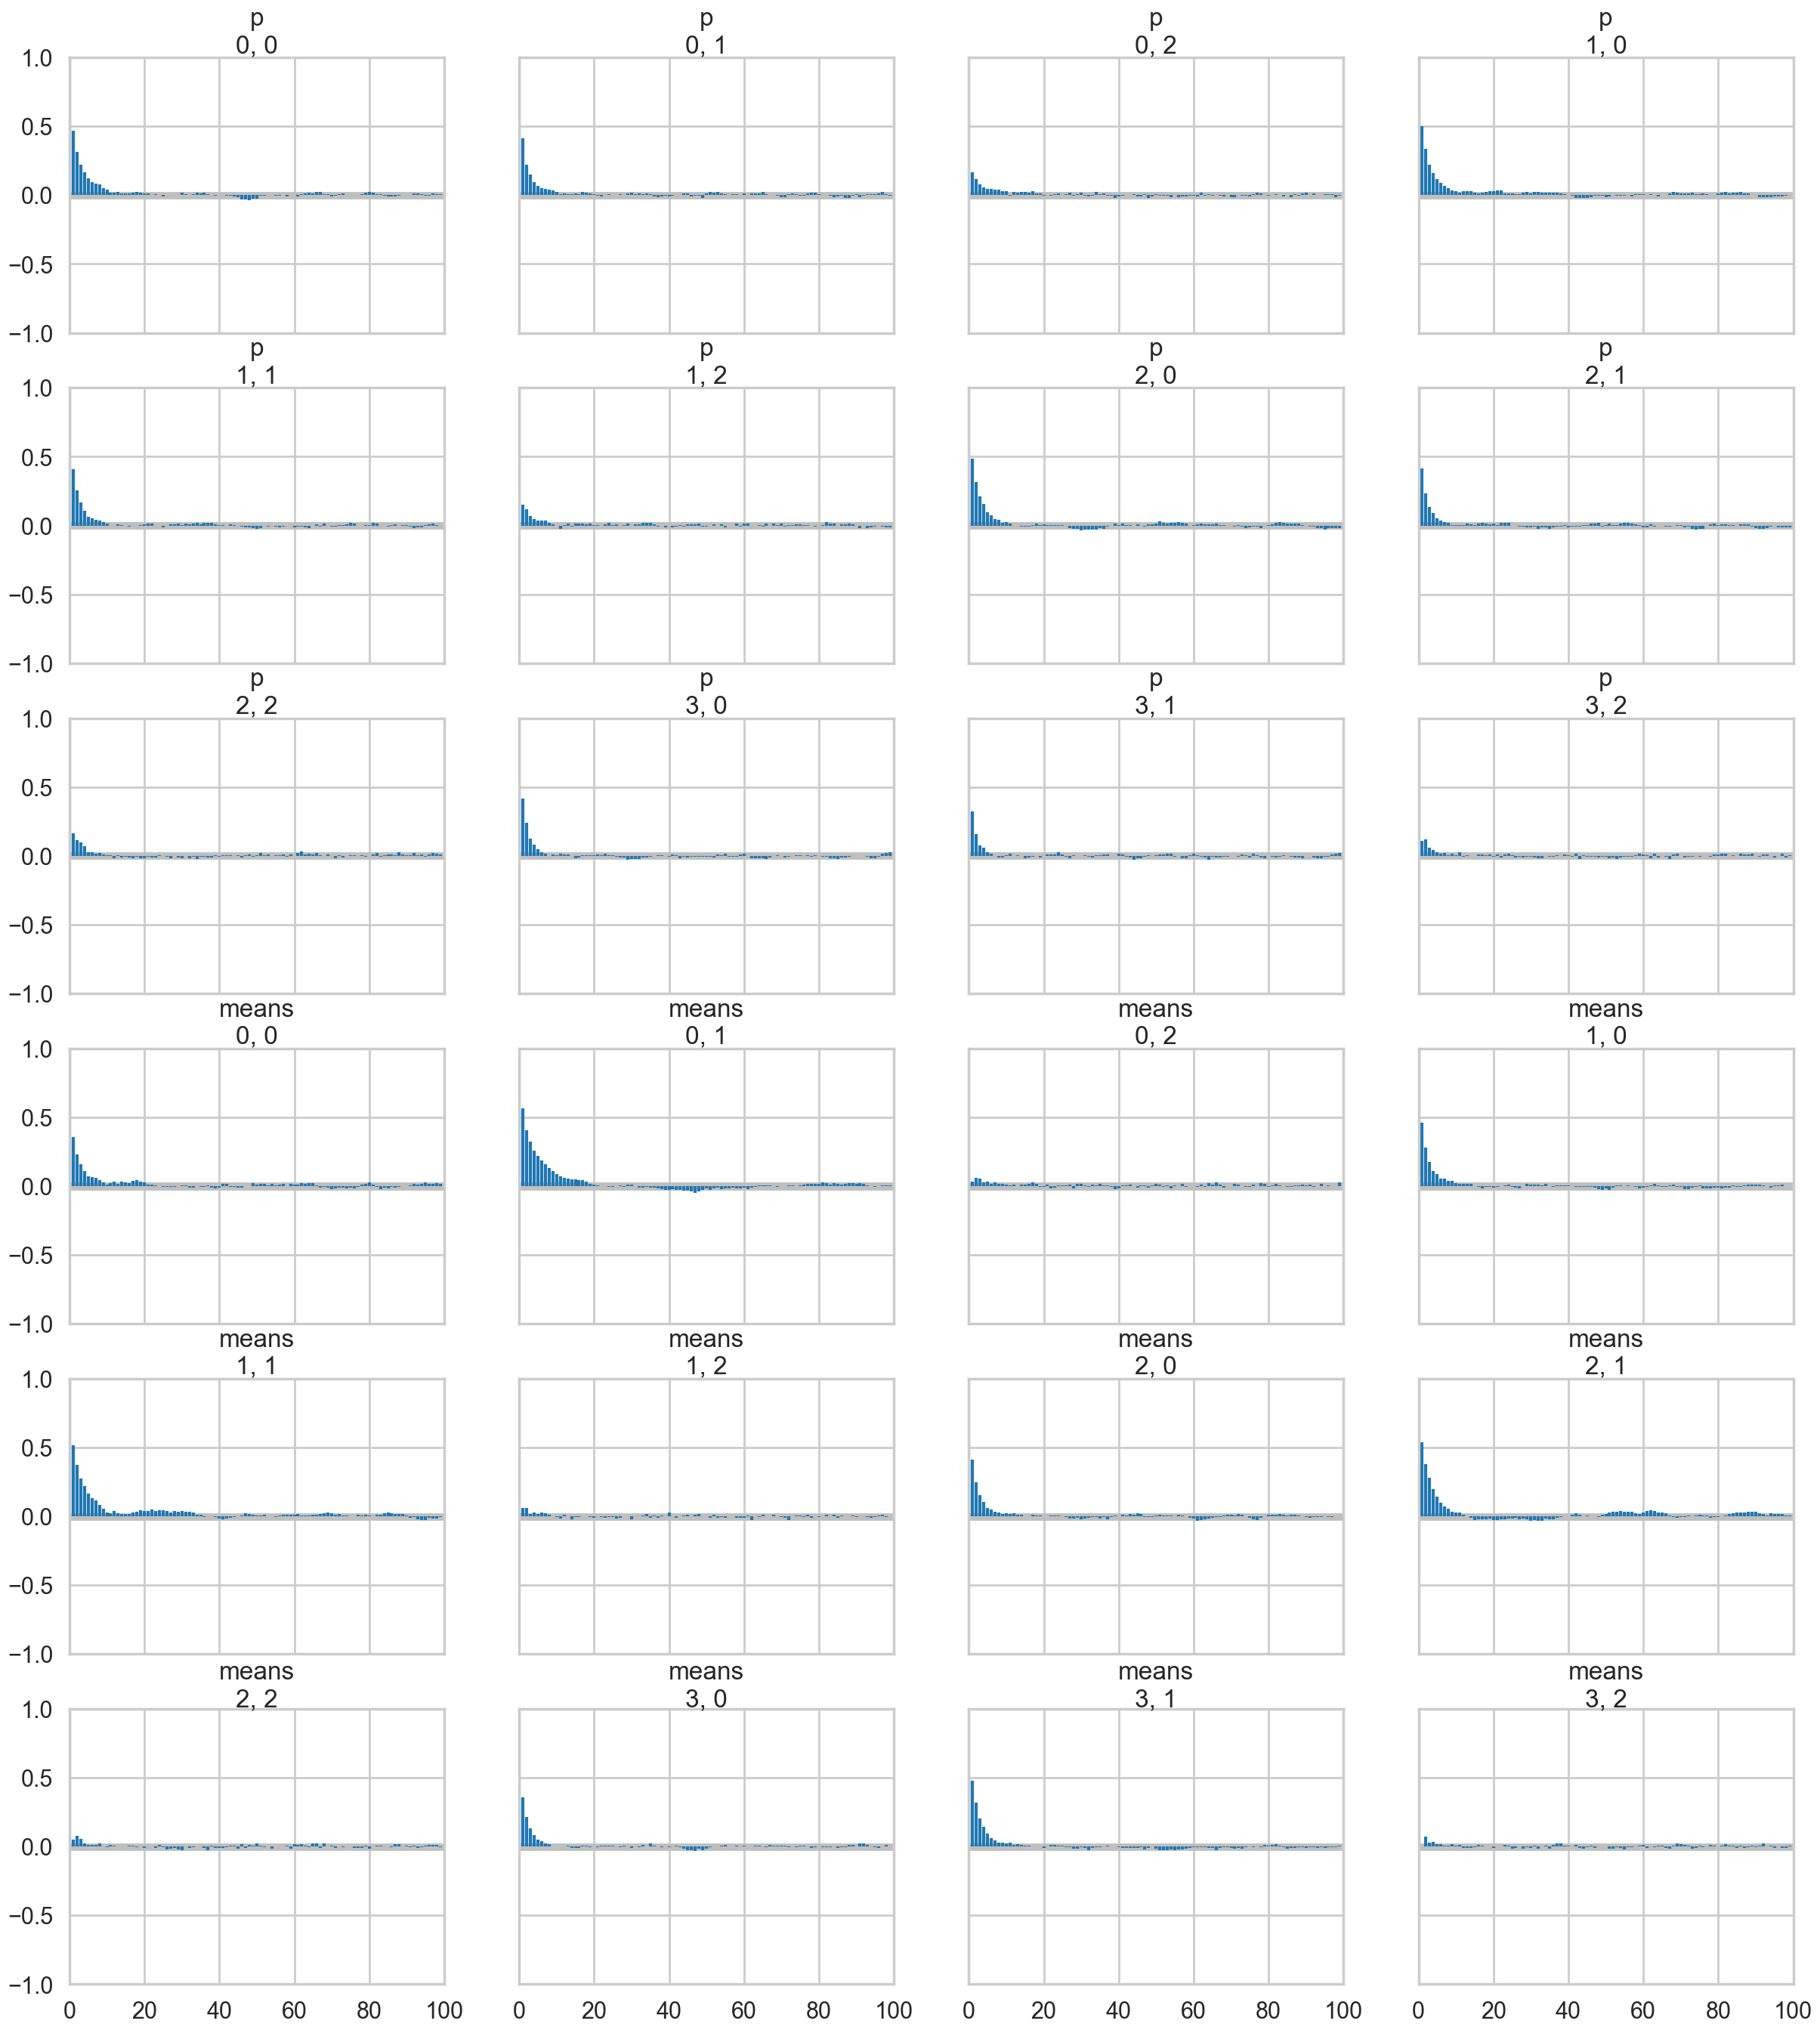

In [7]:
az.plot_autocorr(trace_mof3);

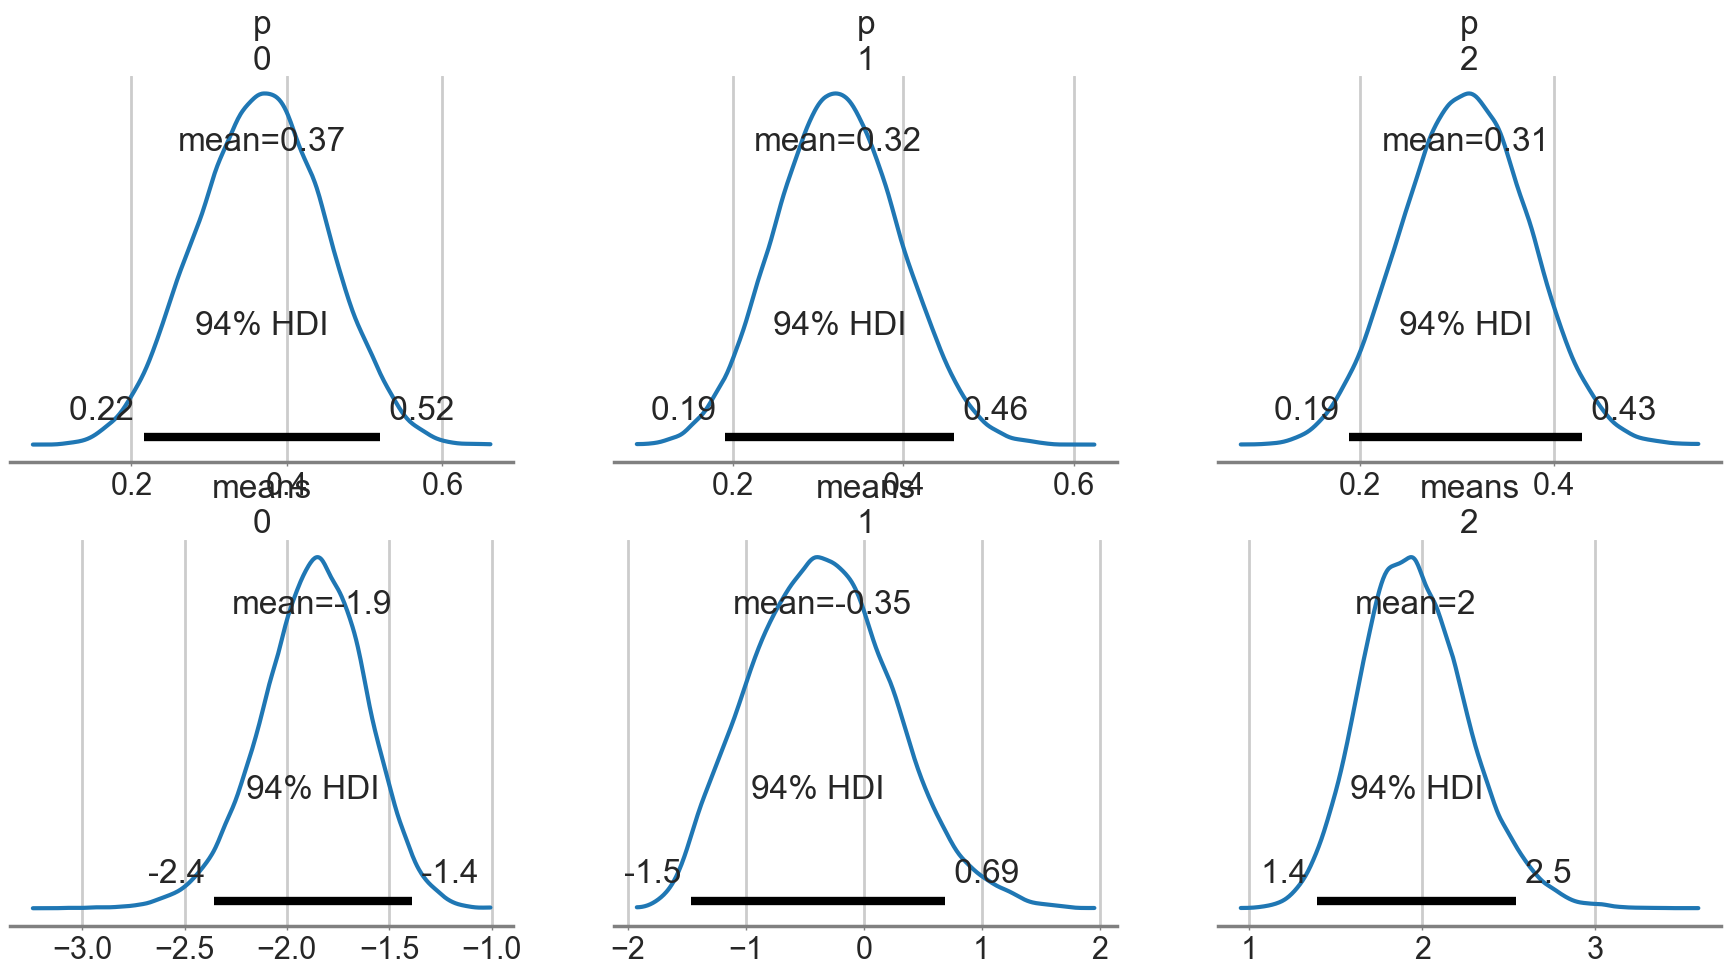

In [8]:
az.plot_posterior(trace_mof3);

**Note:** We run ADVI before posterior predictive sampling because `sample_posterior_predictive` modifies the model graph in a way that prevents ADVI from compiling afterwards.

## ADVI

ADVI also needs a marginalized model as it uses gradient descent.

In [9]:
with mof3:
    approx = pm.fit(n=15000, method="advi")

ERROR (pytensor.graph.rewriting.basic): SequentialGraphRewriter apply <pytensor.tensor.rewriting.elemwise.FusionOptimizer object at 0x10e10dd30>


ERROR (pytensor.graph.rewriting.basic): Traceback:


ERROR (pytensor.graph.rewriting.basic): Traceback (most recent call last):
  File "/Users/rahul/Library/Caches/uv/archive-v0/WJgPh5nRFVZl0DU9tt8M7/lib/python3.14/site-packages/pytensor/graph/rewriting/basic.py", line 289, in apply
    sub_prof = rewriter.apply(fgraph)
  File "/Users/rahul/Library/Caches/uv/archive-v0/WJgPh5nRFVZl0DU9tt8M7/lib/python3.14/site-packages/pytensor/tensor/rewriting/elemwise.py", line 886, in apply
    scalar_inputs, scalar_outputs = self.elemwise_to_scalar(inputs, outputs)
                                    ~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "/Users/rahul/Library/Caches/uv/archive-v0/WJgPh5nRFVZl0DU9tt8M7/lib/python3.14/site-packages/pytensor/tensor/rewriting/elemwise.py", line 538, in elemwise_to_scalar
    scalar_inputs = [replacement[inp] for inp in node.inputs]
                     ~~~~~~~~~~~^^^^^
KeyError: mu



/Users/rahul/Library/Caches/uv/archive-v0/WJgPh5nRFVZl0DU9tt8M7/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Finished [100%]: Average Loss = 213.5


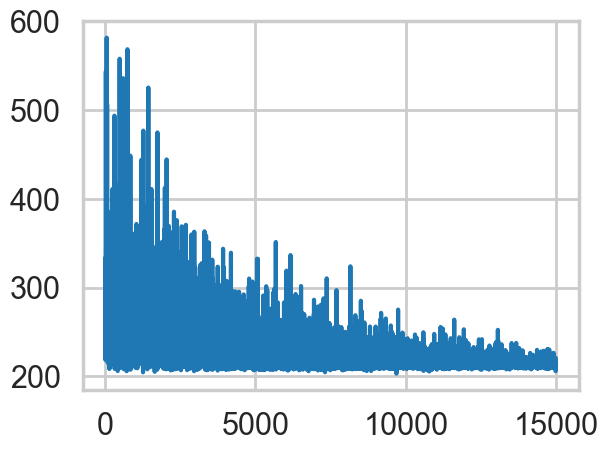

In [10]:
plt.plot(approx.hist)

In [11]:
advi_trace = approx.sample(5000)

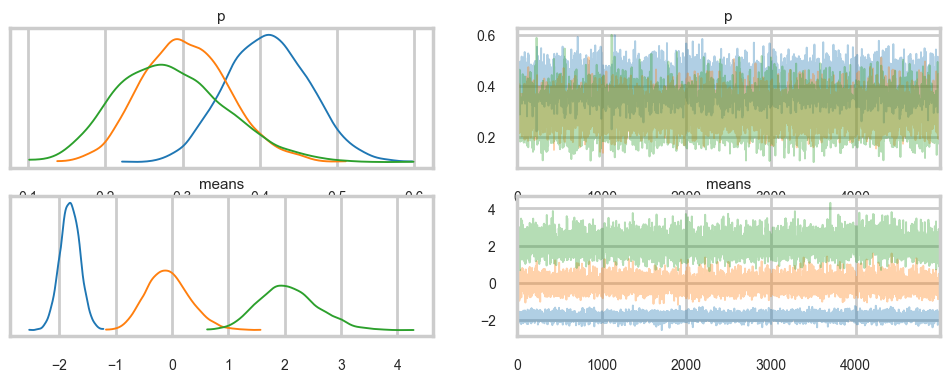

In [12]:
az.plot_trace(advi_trace);

In [13]:
with mof3:
    pred = pm.sample_posterior_predictive(advi_trace)

Sampling: [obs]


/Users/rahul/Library/Caches/uv/archive-v0/WJgPh5nRFVZl0DU9tt8M7/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

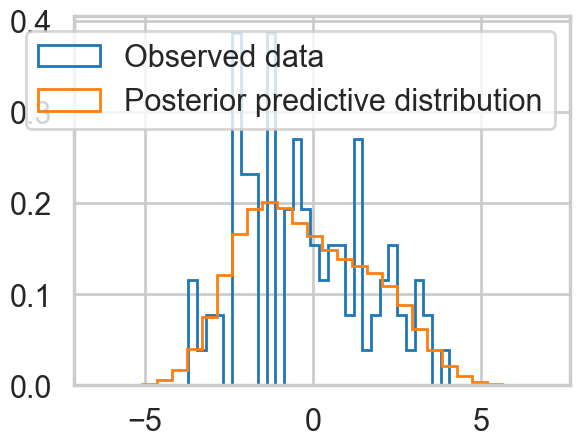

In [14]:
plt.hist(data, bins=30, density=True,
        histtype='step', lw=2,
        label='Observed data');
plt.hist(pred.posterior_predictive['obs'].values.flatten(), bins=30, density=True,
        histtype='step', lw=2,
        label='Posterior predictive distribution');

plt.legend(loc=1);

Ordered, even with Dirichlets, our model fits quite nicely.

## Posterior Predictive

In [15]:
with mof3:
    ppc_trace = pm.sample_posterior_predictive(trace_mof3)

Sampling: [obs]


/Users/rahul/Library/Caches/uv/archive-v0/WJgPh5nRFVZl0DU9tt8M7/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

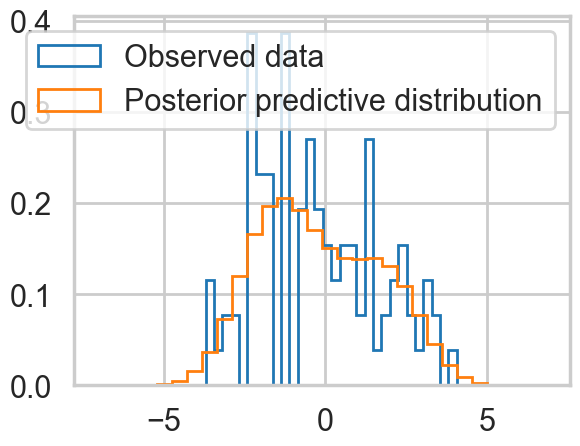

In [16]:
plt.hist(data, bins=30, density=True,
        histtype='step', lw=2,
        label='Observed data');
plt.hist(ppc_trace.posterior_predictive['obs'].values.flatten(), bins=30, density=True,
        histtype='step', lw=2,
        label='Posterior predictive distribution');

plt.legend(loc=1);

You can see the general agreement between these two distributions in this posterior predictive check!

## Marginalizing By Hand

We need to write out the `logp` for the likelihood ourself now, using `logsumexp` to do the sum we need.

In [17]:
from pytensor.tensor import log as pt_log
from pymc.math import logsumexp


def logp_normal(mu, sigma, value):
    # log probability of individual samples
    delta = value - mu
    return (-1 / 2.) * (pt.log(2 * np.pi) + pt.log(sigma*sigma) +
                         (delta * delta) / (sigma * sigma))

# Log likelihood of Gaussian mixture distribution
# In modern pymc, DensityDist logp receives (value, *params)
def logp_gmix(value, mus, pis):
    sigmas = [1., 1., 1.]
    n_components = 3
    n_samples = value.shape[0]
    logps = [pt.log(pis[i]) + logp_normal(mus[i], sigmas[i], value)
             for i in range(n_components)]

    return pt.sum(logsumexp(pt.stacklists(logps)[:, :n_samples], axis=0))

In [18]:
with pm.Model() as mof2:
    p = pm.Dirichlet('p', a=np.array([10., 10., 10.]), shape=3)

    # cluster centers
    means = pm.Normal('means', mu=0, sigma=10, shape=3,
                  transform=pm.distributions.transforms.ordered,
                  initval=np.array([-1, 0, 1]))

    # likelihood for each observed value - pass RVs as positional args
    points = pm.DensityDist('obs', means, p, logp=logp_gmix,
                       observed=data)

In [19]:
with mof2:
    trace_mof2 = pm.sample(10000, tune=2000, target_accept=0.95)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [p, means]


/Users/rahul/Library/Caches/uv/archive-v0/WJgPh5nRFVZl0DU9tt8M7/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_000 tune and 10_000 draw iterations (8_000 + 40_000 draws total) took 20 seconds.


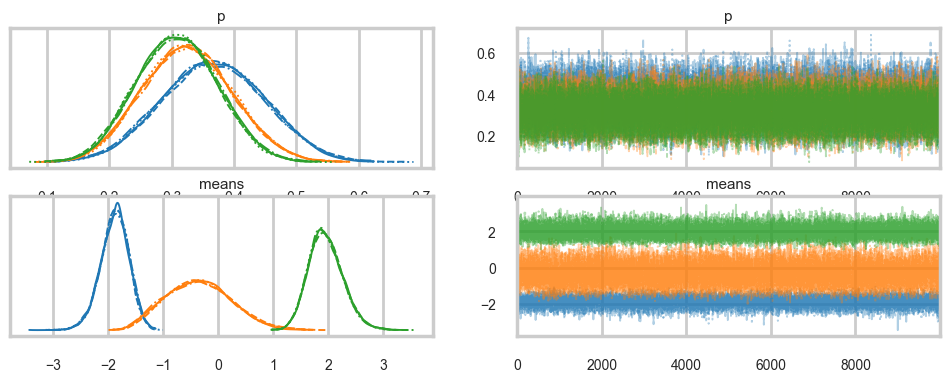

In [20]:
az.plot_trace(trace_mof2);

### Posterior predictive

You cant use `sample_ppc` directly because we did not create a sampling function for our DensityDist. But this is easy to do for a mixture model. Sample a categorical from the p's above, and then sample the appropriate gaussian.

>Exercise: Write a function to do this!

In [21]:
# DensityDist without a random method cannot generate posterior predictive samples
try:
    with mof2:
        ppc_trace2 = pm.sample_posterior_predictive(trace_mof2)
except Exception as e:
    print(f"Expected error: {type(e).__name__}: {e}")

Sampling: [obs]


/Users/rahul/Library/Caches/uv/archive-v0/WJgPh5nRFVZl0DU9tt8M7/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Expected error: NotImplementedError: Attempted to run random on the CustomDist 'CustomDist_obs', but this method had not been provided when the distribution was constructed. Please re-build your model and provide a callable to 'CustomDist_obs's random keyword argument.

Apply node that caused the error: CustomDist_obs_rv{"(),()->()"}(RNG(<Generator(PCG64) at 0x11450AEA0>), [100], means, p)
Toposort index: 0
Inputs types: [RandomGeneratorType, TensorType(int64, shape=(1,)), TensorType(float64, shape=(3,)), TensorType(float64, shape=(3,))]
Inputs shapes: ['No shapes', (1,), (3,), (3,)]
Inputs strides: ['No strides', (8,), (8,), (8,)]
Inputs values: [Generator(PCG64) at 0x11450AEA0, array([100]), array([-1.83036371,  0.62123309,  2.27071694]), array([0.42944502, 0.31289165, 0.25766333])]
Outputs clients: [[output[2](CustomDist_obs_rv{"(),()->()"}.0)], [output[1](obs), DeepCopyOp(obs)]]

Backtrace when the node is created (use PyTensor flag traceback__limit=N to make it longer):
  File "/U

We do quite well!

## A much more separated gaussian model

In [22]:
data2=np.loadtxt("data/3g.dat")

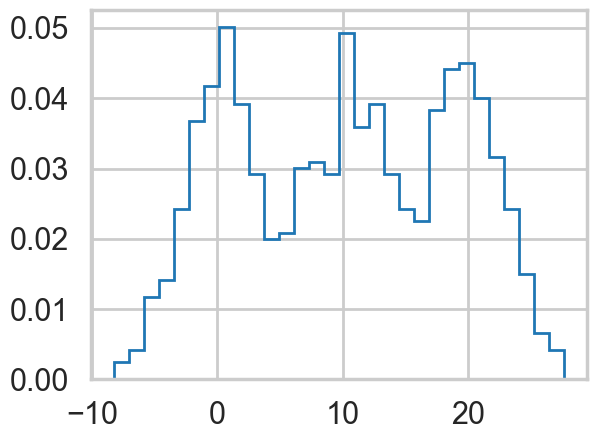

In [23]:
plt.hist(data2, bins=30, density=True,
        histtype='step', lw=2,
        label='Observed data');

Notice below the use of Potentials. These ensure that there are (a) some members in each cluster and (b) provide us a fifferent way to specify the ordering. This works aby adding log-probability to a model to prevent the sampler going to places where this is negative infinity.

In [24]:
## Class Model for 3 gaussian mixture

with pm.Model() as mofsep:
    p = pm.Dirichlet('p', a=np.array([2., 2., 2.]), shape=3)
    # ensure all clusters have some points
    p_min_potential = pm.Potential('p_min_potential', pt.switch(pt.min(p) < .1, -np.inf, 0))

    # cluster centers
    means = pm.Normal('means', mu=[0, 10, 20], sigma=5, shape=3)

    order_means_potential = pm.Potential('order_means_potential',
                                         pt.switch(means[1]-means[0] < 0, -np.inf, 0)
                                         + pt.switch(means[2]-means[1] < 0, -np.inf, 0))
                                         
    # measurement error
    sds = pm.HalfCauchy('sds', beta=5, shape=3)


    # likelihood for each observed value
    points = pm.NormalMixture('obs', p, mu=means, sigma=sds, observed=data2)



In [25]:
with mofsep:
    tracesep = pm.sample(10000, tune=2000, target_accept=0.95)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [p, means, sds]


/Users/rahul/Library/Caches/uv/archive-v0/WJgPh5nRFVZl0DU9tt8M7/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_000 tune and 10_000 draw iterations (8_000 + 40_000 draws total) took 35 seconds.


**Note:** We run ADVI before posterior predictive sampling because `sample_posterior_predictive` modifies the model graph in a way that prevents ADVI from compiling afterwards.

This samples very cleanly and we can do ADVI as well...

In [26]:
with mofsep:
    approx_sep = pm.fit(n=15000, method="advi")

ERROR (pytensor.graph.rewriting.basic): SequentialGraphRewriter apply <pytensor.tensor.rewriting.elemwise.FusionOptimizer object at 0x10e10dd30>


ERROR (pytensor.graph.rewriting.basic): Traceback:


ERROR (pytensor.graph.rewriting.basic): Traceback (most recent call last):
  File "/Users/rahul/Library/Caches/uv/archive-v0/WJgPh5nRFVZl0DU9tt8M7/lib/python3.14/site-packages/pytensor/graph/rewriting/basic.py", line 289, in apply
    sub_prof = rewriter.apply(fgraph)
  File "/Users/rahul/Library/Caches/uv/archive-v0/WJgPh5nRFVZl0DU9tt8M7/lib/python3.14/site-packages/pytensor/tensor/rewriting/elemwise.py", line 886, in apply
    scalar_inputs, scalar_outputs = self.elemwise_to_scalar(inputs, outputs)
                                    ~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "/Users/rahul/Library/Caches/uv/archive-v0/WJgPh5nRFVZl0DU9tt8M7/lib/python3.14/site-packages/pytensor/tensor/rewriting/elemwise.py", line 538, in elemwise_to_scalar
    scalar_inputs = [replacement[inp] for inp in node.inputs]
                     ~~~~~~~~~~~^^^^^
KeyError: mu



/Users/rahul/Library/Caches/uv/archive-v0/WJgPh5nRFVZl0DU9tt8M7/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Finished [100%]: Average Loss = 3,478.4


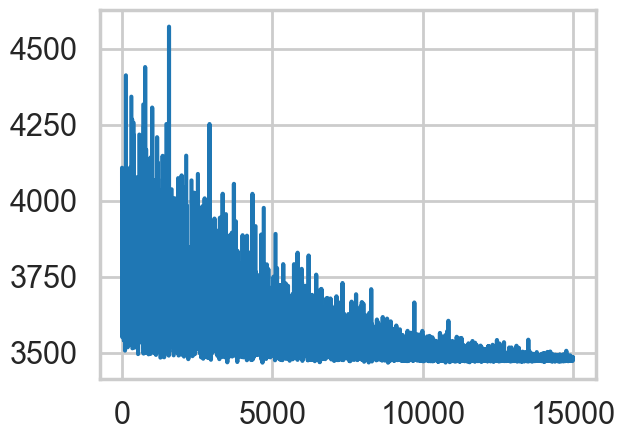

In [27]:
plt.plot(approx_sep.hist)

In [28]:
advi_trace_sep = approx_sep.sample(5000)

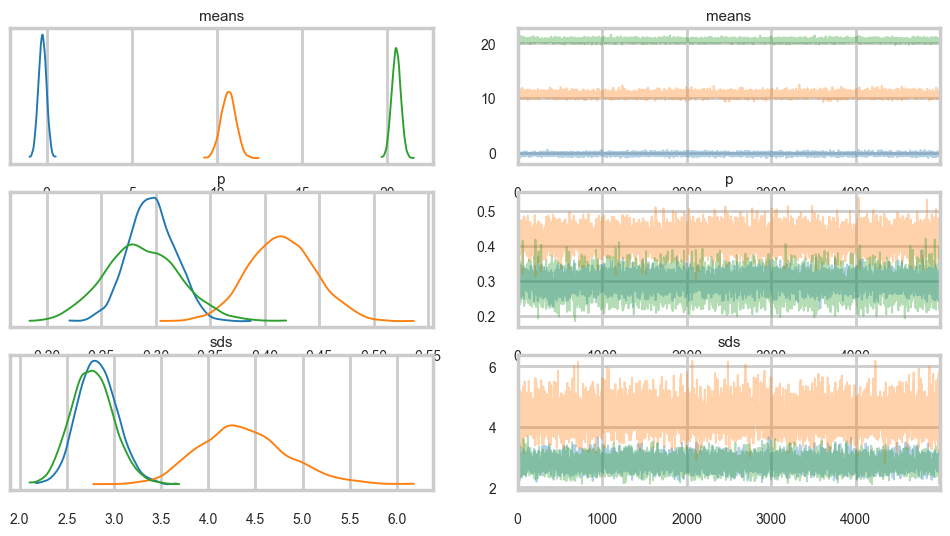

In [29]:
az.plot_trace(advi_trace_sep);

In [30]:
with mofsep:
    predsep = pm.sample_posterior_predictive(advi_trace_sep)

/var/folders/wq/mr3zj9r14dzgjnq9rjx_vqbc0000gn/T/ipykernel_15246/2357717413.py:2: UserWarning: The effect of Potentials on other parameters is ignored during posterior predictive sampling. This is likely to lead to invalid or biased predictive samples.
  predsep = pm.sample_posterior_predictive(advi_trace_sep)
Sampling: [obs]


/Users/rahul/Library/Caches/uv/archive-v0/WJgPh5nRFVZl0DU9tt8M7/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

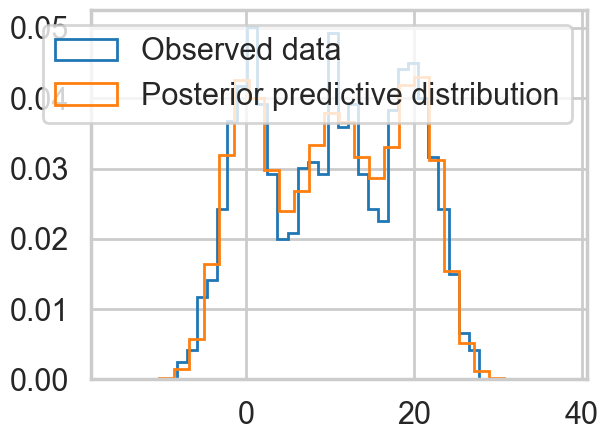

In [31]:
plt.hist(data2, bins=30, density=True,
        histtype='step', lw=2,
        label='Observed data');
plt.hist(predsep.posterior_predictive['obs'].values.flatten(), bins=30, density=True,
        histtype='step', lw=2,
        label='Posterior predictive distribution');

plt.legend(loc=1);

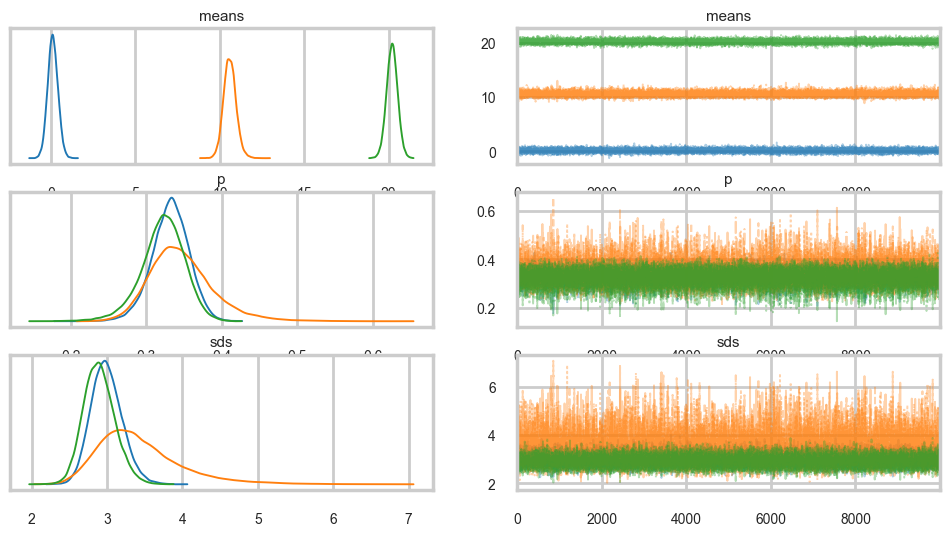

In [32]:
az.plot_trace(tracesep, combined=True);

In [33]:
with mofsep:
    ppc_tracesep = pm.sample_posterior_predictive(tracesep)

/var/folders/wq/mr3zj9r14dzgjnq9rjx_vqbc0000gn/T/ipykernel_15246/1303473296.py:2: UserWarning: The effect of Potentials on other parameters is ignored during posterior predictive sampling. This is likely to lead to invalid or biased predictive samples.
  ppc_tracesep = pm.sample_posterior_predictive(tracesep)
Sampling: [obs]


/Users/rahul/Library/Caches/uv/archive-v0/WJgPh5nRFVZl0DU9tt8M7/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

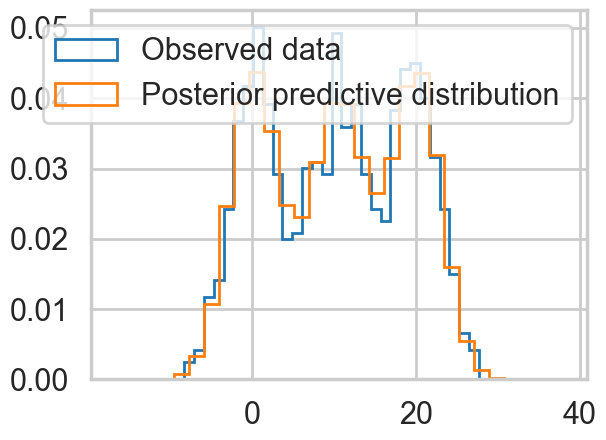

In [34]:
plt.hist(data2, bins=30, density=True,
        histtype='step', lw=2,
        label='Observed data');
plt.hist(ppc_tracesep.posterior_predictive['obs'].values.flatten(), bins=30, density=True,
        histtype='step', lw=2,
        label='Posterior predictive distribution');

plt.legend(loc=1);